In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from scipy import stats

plt.style.use("default")

resultsdir = "../part1_refoldunfold/2_structure_prediction/parsed_results/"
res2_dir = "../part2_gpc_training/2_structure_prediction/parsed_results"


df_colabfold = pd.read_csv(f"{resultsdir}/af_res_colabfold_info.csv", index_col=0)
sp_colabfold = pd.read_csv(f"{resultsdir}/sp_res_colabfold_info.csv", index_col=0)

test2_colabfold = pd.read_csv(f"{res2_dir}/test2_colabfold_info.csv")
aflike_colabfold = pd.read_csv(f"{res2_dir}/pseudo_antifams_colabfold_info.csv")
test50_colabfold = pd.read_csv(f"{res2_dir}/test50_colabfold_info.csv")
train_colabfold = pd.read_csv(f"{res2_dir}/train_colabfold_info.csv")


sp_colabfold = pd.concat(
    [test50_colabfold, train_colabfold, sp_colabfold, test2_colabfold]
)

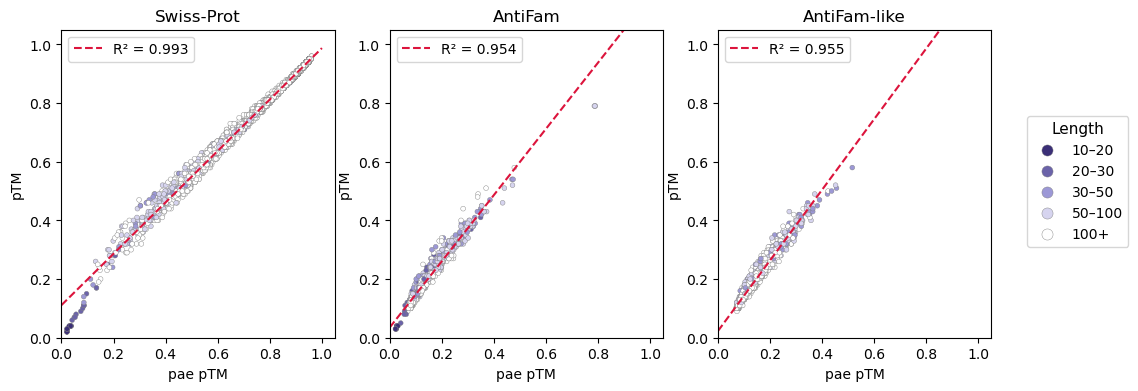

In [2]:
# Length bins and labels
bins = [10, 20, 30, 50, 100, np.inf]
labels = ["10–20", "20–30", "30–50", "50–100", "100+"]

# Model-specific color palettes
model_colors = {
    "AlphaFold3": ["#b3472d", "#ff7f50", "#ff9f80", "#ffd8cc", "#ffffff"],
    "AlphaFold2": ["#3b2f77", "#6b63a9", "#9c98d6", "#d6d4ef", "#ffffff"],
}


def compare_scores(
    df, ax=None, title=None, color_by_length=False, model="AlphaFold2", show_legend=True
):
    # plot pae pTM vs pTM with line of best fit and correlation
    if ax is None:
        fig, ax = plt.subplots(figsize=(3, 3))

    x = df["pae pTM"]
    y = df["pTM"]

    if color_by_length and "length" in df.columns:
        df = df.copy()
        df["length_bin"] = pd.cut(df["length"], bins=bins, labels=labels, right=False)

        base_colors = model_colors[model]
        color_mapping = dict(zip(labels, base_colors))
        point_colors = df["length_bin"].map(color_mapping)

        ax.scatter(x, y, s=12, c=point_colors, edgecolors="gray", linewidths=0.3)
    else:
        ax.scatter(x, y, s=12, c="darkslateblue")

    mask = ~(np.isnan(x) | np.isnan(y))
    slope, intercept, r_value, p_value, std_err = stats.linregress(x[mask], y[mask])
    x_line = np.linspace(0, 1, 100)
    y_line = slope * x_line + intercept
    ax.plot(
        x_line,
        y_line,
        c="crimson",
        linestyle="--",
        linewidth=1.5,
        label=f"R² = {r_value**2:.3f}",
    )

    ax.set_xlim(0, 1.05)
    ax.set_ylim(0, 1.05)
    ax.set_xticks(np.arange(0, 1.1, 0.2))
    ax.set_yticks(np.arange(0, 1.1, 0.2))
    ax.set_xlabel("pae pTM")
    ax.set_ylabel("pTM")
    ax.legend(loc="upper left", fontsize=10)

    if title:
        ax.set_title(title, fontsize=12)

    return ax


def add_length_legend(fig, model="AlphaFold2"):
    base_colors = model_colors[model]
    legend_elements = [
        Line2D(
            [0],
            [0],
            marker="o",
            color="w",
            markerfacecolor=color,
            markersize=8,
            label=label,
            markeredgecolor="gray",
            markeredgewidth=0.3,
        )
        for label, color in zip(labels, base_colors)
    ]
    fig.legend(
        handles=legend_elements,
        title="Length",
        loc="center right",
        fontsize=10,
        title_fontsize=11,
        bbox_to_anchor=(1.02, 0.5),
    )


# 3-plot grid for AF2
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

compare_scores(
    sp_colabfold,
    ax=axes[0],
    title="Swiss-Prot",
    color_by_length=True,
    model="AlphaFold2",
)
compare_scores(
    df_colabfold, ax=axes[1], title="AntiFam", color_by_length=True, model="AlphaFold2"
)
compare_scores(
    aflike_colabfold,
    ax=axes[2],
    title="AntiFam-like",
    color_by_length=True,
    model="AlphaFold2",
)

add_length_legend(fig, model="AlphaFold2")
plt.savefig("paeptm_ptm.png", bbox_inches="tight", dpi=300)
plt.show()